In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
print(sklearn.)

In [2]:
RANDOM_STATE   = 42


In [3]:
FEATURES       = ["Price", "Overall Rating", "Number Sold"]


# Collecting Data

In [4]:
df = pd.read_csv("../datasets/PRDECT-ID Dataset.csv")
df.head()

,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy


In [5]:
X = df[["Price", "Overall Rating", "Number Sold"]]

# EDA

# Data Pre Processing

In [6]:
df["log_price"]      = np.log1p(df["Price"])
df["log_sold_count"] = np.log1p(df["Number Sold"])

In [7]:
SCALED_FEATURES = ["log_price", "Overall Rating", "log_sold_count"]
X_raw = df[SCALED_FEATURES]

In [8]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Training

In [9]:
K_RANGE    = range(2, 11)
inertias   = []
silhouettes = []

In [10]:
for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl))
    print(f"  K={k}  Inertia={km.inertia_:,.1f}  Silhouette={silhouettes[-1]:.4f}")


  K=2  Inertia=11,361.8  Silhouette=0.2788
  K=3  Inertia=8,450.2  Silhouette=0.2994
  K=4  Inertia=7,216.6  Silhouette=0.2557
  K=5  Inertia=6,310.9  Silhouette=0.2605
  K=6  Inertia=5,599.1  Silhouette=0.2699
  K=7  Inertia=5,102.3  Silhouette=0.2762
  K=8  Inertia=4,663.6  Silhouette=0.2604
  K=9  Inertia=4,312.5  Silhouette=0.2727
  K=10  Inertia=4,038.6  Silhouette=0.2727


In [11]:
best_k = K_RANGE.start + silhouettes.index(max(silhouettes))


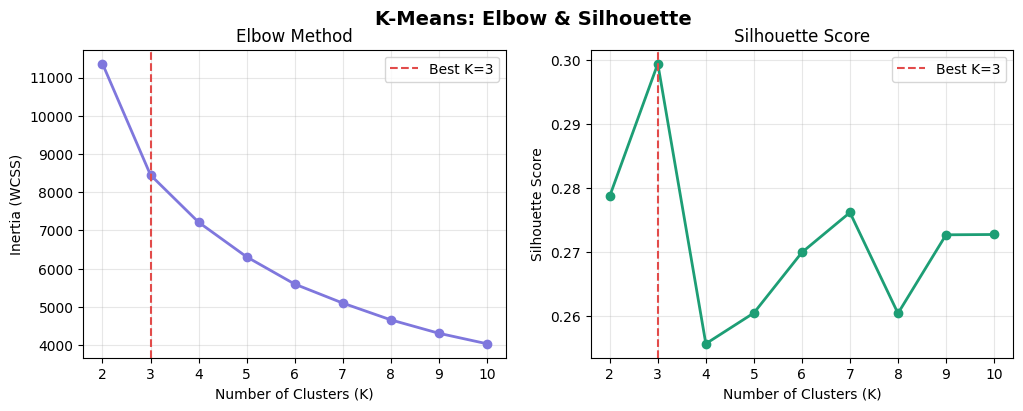

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("K-Means: Elbow & Silhouette", fontsize=14, fontweight="bold")

axes[0].plot(list(K_RANGE), inertias, marker="o", color="#7F77DD", linewidth=2)
axes[0].axvline(best_k, color="#E24B4A", linestyle="--", label=f"Best K={best_k}")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(list(K_RANGE), silhouettes, marker="o", color="#1D9E75", linewidth=2)
axes[1].axvline(best_k, color="#E24B4A", linestyle="--", label=f"Best K={best_k}")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score")
axes[1].legend()
axes[1].grid(alpha=0.3)

In [13]:
kmeans       = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
km_labels    = kmeans.fit_predict(X_scaled)
df["km_cluster"] = km_labels

In [14]:
centroids_scaled = kmeans.cluster_centers_
centroids_raw    = scaler.inverse_transform(centroids_scaled)
centroid_df      = pd.DataFrame(centroids_raw, columns=SCALED_FEATURES)
centroid_df["cluster"] = range(best_k)

In [15]:
price_rank = centroid_df["log_price"].rank()
rating_rank = centroid_df["Overall Rating"].rank()
sold_rank   = centroid_df["log_sold_count"].rank()
score_premium     = price_rank + rating_rank
score_mass_market = sold_rank + (best_k + 1 - price_rank)
score_failed      = (best_k + 1 - rating_rank) + (best_k + 1 - sold_rank)


In [16]:
used = set()
label_map = {}
for name, scores in [("Premium", score_premium),
                     ("Massal", score_mass_market),
                     ("Gagal", score_failed)]:
    best = scores.idxmax()
    while best in used:
        scores[best] = -999
        best = scores.idxmax()
    label_map[best] = name
    used.add(best)

In [17]:
for idx in range(best_k):
    if idx not in label_map:
        label_map[idx] = "Niche"

df["km_segment"] = df["km_cluster"].map(label_map)

In [18]:
print("\n  Cluster centroids (original scale):")
centroid_display = df.groupby("km_segment")[FEATURES].mean().round(2)
print(centroid_display.to_string())



  Cluster centroids (original scale):
                Price  Overall Rating  Number Sold
km_segment                                        
Gagal        99968.97            4.71      2873.98
Massal       32498.55            4.88     35984.05
Premium     534473.17            4.92      2931.16


# Evaluate

# Save Model

In [19]:
import joblib


In [20]:
joblib.dump(kmeans, f"./kmeans_model.pkl")


['./kmeans_model.pkl']

In [21]:
joblib.dump(scaler, "./scaler.pkl")

['./scaler.pkl']